# Pork Dataset Summary

This notebook summarizes image counts by pork part, sample number, and time-frame distribution.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = 'csv_outputs/all_datasets_combined.csv'
df = pd.read_csv(csv_path)

df['sample_number'] = df['sample_number'].fillna('').replace('', 'Public/NA')
df['meat_part'] = df['meat_part'].fillna('Unknown').replace('', 'Unknown')
df['time_frame'] = df['time_frame'].fillna('')

print(f'Total images: {len(df):,}')
df.head()

Total images: 12,778


,image_file_name,sample_number,meat_part,label,time_frame,file_destination
0,20260429_042402.jpg,3.0,Pork Belly,fresh,00:00:00,E:\Thesis Code\Pork Belly - Sample 3\Fresh - 0...
1,20260429_042501.jpg,3.0,Pork Belly,fresh,00:04:06,E:\Thesis Code\Pork Belly - Sample 3\Fresh - 0...
2,20260429_042601.jpg,3.0,Pork Belly,fresh,00:08:12,E:\Thesis Code\Pork Belly - Sample 3\Fresh - 0...
3,20260429_042701.jpg,3.0,Pork Belly,fresh,00:12:18,E:\Thesis Code\Pork Belly - Sample 3\Fresh - 0...
4,20260429_042801.jpg,3.0,Pork Belly,fresh,00:16:25,E:\Thesis Code\Pork Belly - Sample 3\Fresh - 0...


In [2]:
# Count all images per pork part and sample number
part_sample_counts = (
    df.groupby(['meat_part', 'sample_number'])
      .size()
      .reset_index(name='image_count')
      .sort_values(['meat_part', 'sample_number'])
)
part_sample_counts

,meat_part,sample_number,image_count
0,Pork Belly,3.0,2393
1,Pork Belly,4.0,2847
2,Pork Shoulder,1.0,2668
3,Pork Shoulder,2.0,2606
4,Unknown,Public/NA,2264


In [3]:
# Pivot table for easier reading
pivot_counts = pd.pivot_table(
    part_sample_counts,
    index='meat_part',
    columns='sample_number',
    values='image_count',
    fill_value=0
)
pivot_counts

sample_number,1.0,2.0,3.0,4.0,Public/NA
meat_part,,,,,
Pork Belly,0.0,0.0,2393.0,2847.0,0.0
Pork Shoulder,2668.0,2606.0,0.0,0.0,0.0
Unknown,0.0,0.0,0.0,0.0,2264.0


In [4]:
# Time-frame distribution (excluding Public/NA rows with empty time_frame)
timed = df[df['time_frame'] != ''].copy()
time_dist = (
    timed.groupby(['sample_number', 'label', 'time_frame'])
         .size()
         .reset_index(name='image_count')
         .sort_values(['sample_number', 'label', 'time_frame'])
)
time_dist.head(30)

,sample_number,label,time_frame,image_count
0,1.0,fresh,00:00:00,1
1,1.0,fresh,00:01:32,1
2,1.0,fresh,00:03:03,1
3,1.0,fresh,00:04:35,1
4,1.0,fresh,00:06:07,1
5,1.0,fresh,00:07:39,1
6,1.0,fresh,00:09:10,1
7,1.0,fresh,00:10:42,1
8,1.0,fresh,00:12:14,1
9,1.0,fresh,00:13:45,1


In [5]:
# Coarser hourly distribution for quick interpretation
timed['hour_bucket'] = timed['time_frame'].str.slice(0, 2).astype(int)
hourly = (
    timed.groupby(['sample_number', 'label', 'hour_bucket'])
         .size()
         .reset_index(name='image_count')
         .sort_values(['sample_number', 'label', 'hour_bucket'])
)
hourly.head(30)

,sample_number,label,hour_bucket,image_count
0,1.0,fresh,0,40
1,1.0,fresh,1,39
2,1.0,fresh,2,39
3,1.0,fresh,3,39
4,1.0,fresh,4,40
5,1.0,fresh,5,39
6,1.0,fresh,6,39
7,1.0,fresh,7,39
8,1.0,fresh,8,1
9,1.0,not fresh,8,60


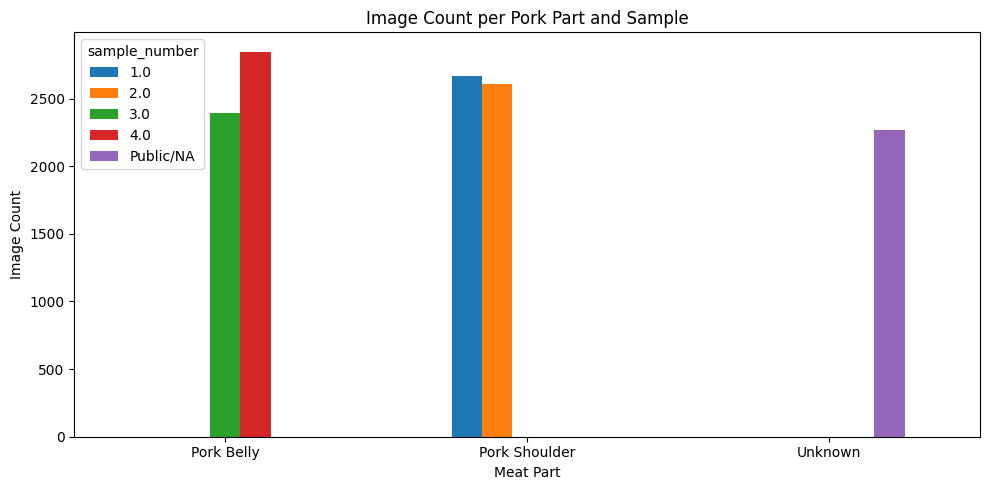

In [6]:
# Plot image counts by pork part and sample
plot_df = part_sample_counts.copy()
pivot_plot = plot_df.pivot(index='meat_part', columns='sample_number', values='image_count').fillna(0)
pivot_plot.plot(kind='bar', figsize=(10, 5))
plt.title('Image Count per Pork Part and Sample')
plt.xlabel('Meat Part')
plt.ylabel('Image Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

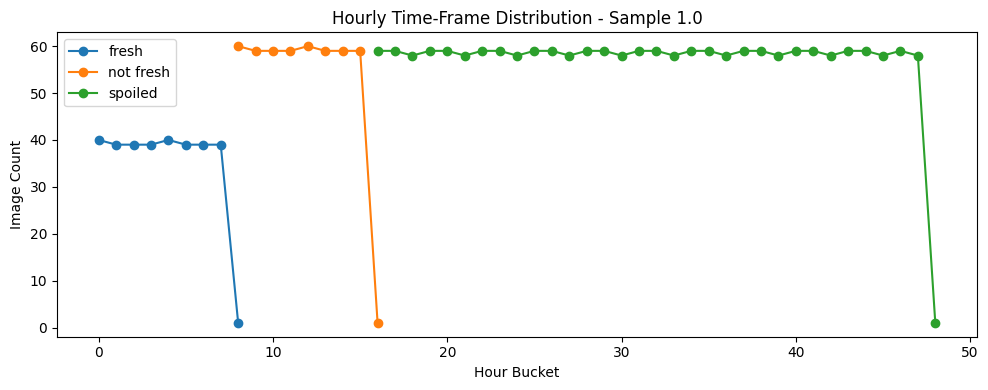

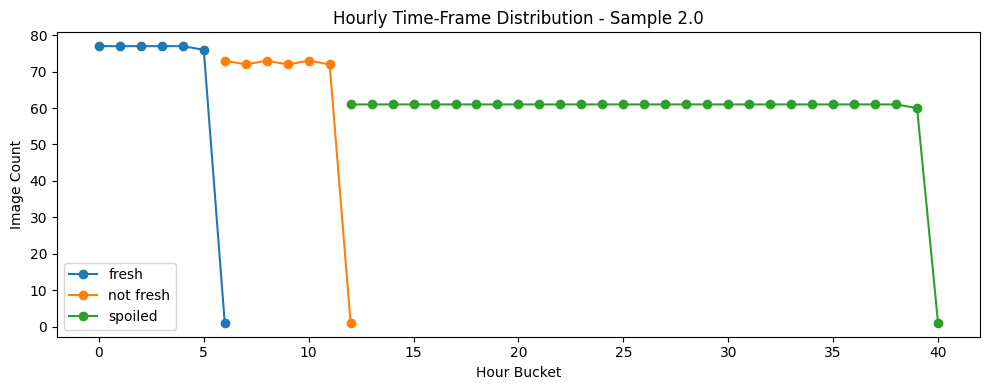

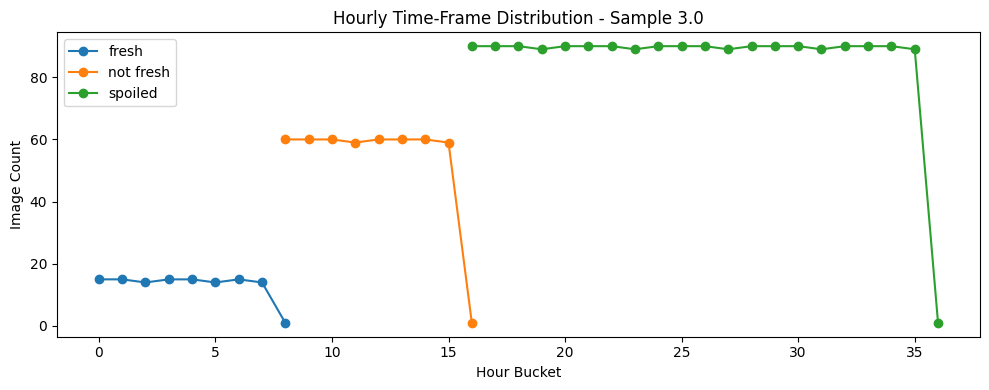

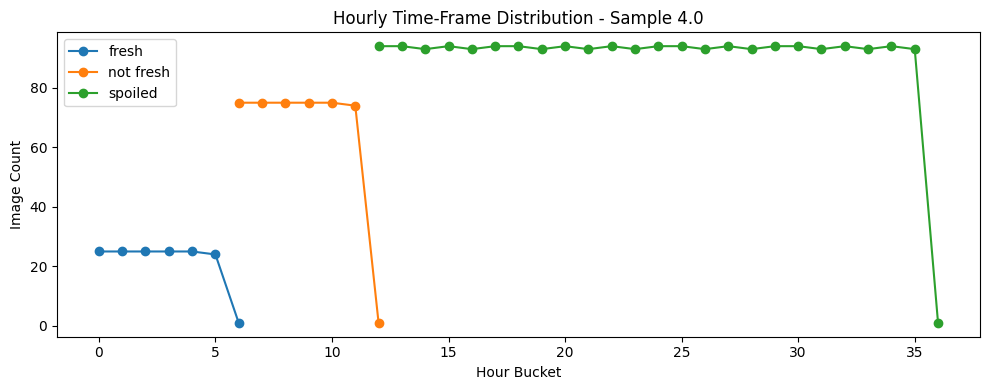

In [7]:
# Plot hourly time-frame distribution by label
for sample in sorted(hourly['sample_number'].unique(), key=lambda x: str(x)):
    sdf = hourly[hourly['sample_number'] == sample]
    if sdf.empty:
        continue
    plt.figure(figsize=(10, 4))
    for label in ['fresh', 'not fresh', 'spoiled']:
        ldf = sdf[sdf['label'] == label]
        if not ldf.empty:
            plt.plot(ldf['hour_bucket'], ldf['image_count'], marker='o', label=label)
    plt.title(f'Hourly Time-Frame Distribution - Sample {sample}')
    plt.xlabel('Hour Bucket')
    plt.ylabel('Image Count')
    plt.legend()
    plt.tight_layout()
    plt.show()